# 📚 Pipeline de Entendimento de Dados (Data Understanding)

**Projeto:** Análise e Predição de Alarmes (`Is_Dont_Go`)  
**Fase:** Compreensão e Exploração Inicial dos Dados

Este notebook realiza a inspeção estrutural, análise exploratória visual e levantamento de inconsistências nas bases brutas de telemetria e regras de negócio. O objetivo principal é mapear o comportamento das variáveis, identificar problemas de tipagem e levantar hipóteses antes de prosseguir para a engenharia de atributos.

---

## 🔍 1. Configuração do Ambiente e Importações

In [12]:
!pip install pandas

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

## 🔍 2. Carregamento e Inspeção Inicial das Bases

Nesta etapa, importamos a base de dados de telemetria referente ao mês de Janeiro (`jan.csv`) e o arquivo auxiliar contendo as regras de negócio dos alarmes.

> 💡 **Nota:** As colunas `Valor` e `Classe` podem disparar um alerta de tipo misto (`DtypeWarning`) devido à presença de caracteres regionais (como vírgulas) ou preenchimentos inconsistentes. Esse comportamento será mapeado e tratado nas seções de higienização.

In [14]:
seed = 42
path = "../data/telemetry/processed"
january = "../data/telemetry/processed/jan.csv"
#jan = pd.read_csv(january)
jan = pd.read_csv(january, dtype={"Valor": str, "Classe": str})

path_alarmes = "../Material/"
alarmes = os.path.join(path_alarmes, "Alarmes - Regra de Negocio.csv")
alar = pd.read_csv(alarmes)

## 🔍 3. Inspeção Estrutural das Amostras

Visualização rápida das primeiras linhas de cada DataFrame para compreender a disposição das colunas, nomenclatura dos atributos e os formatos iniciais das variáveis.

In [15]:
head_jan = jan.head()
head_alarmes = alar.head()
#head_jan
head_alarmes


,TIPO,EVENTO,SITUACAO,QTD,TEMPO,NIVEL
0,ALARME OEM,Low Transmission Oil Level,Mediante alarme nível 3,2,360,Muito Alto
1,ALARME OEM,Low Transmission Oil Level,Mediante cinco alarmes nivel 2 consecutivos.,5,360,Muito alto
2,ALARME OEM,Transmission Oil Level - Active,Mediante alarme nível 3,2,360,Muito Alto
3,ALARME OEM,Engine Coolant Level - Active,Mediante alarme nível 3,1,0,Muito Alto
4,ALARME OEM,Engine Coolant Level - Active,Mediante dez alarmes nivel 2 consecutivos.,10,360,Alto


## 🔍 4. Exploração Visual por Transposição de Dados

Para facilitar a auditoria visual de registros específicos em bases de dados com muitas colunas (tabelas largas), aplicamos uma técnica de transposição (.T). O código abaixo estiliza e exporta essa visão estruturada para análise em alta resolução.

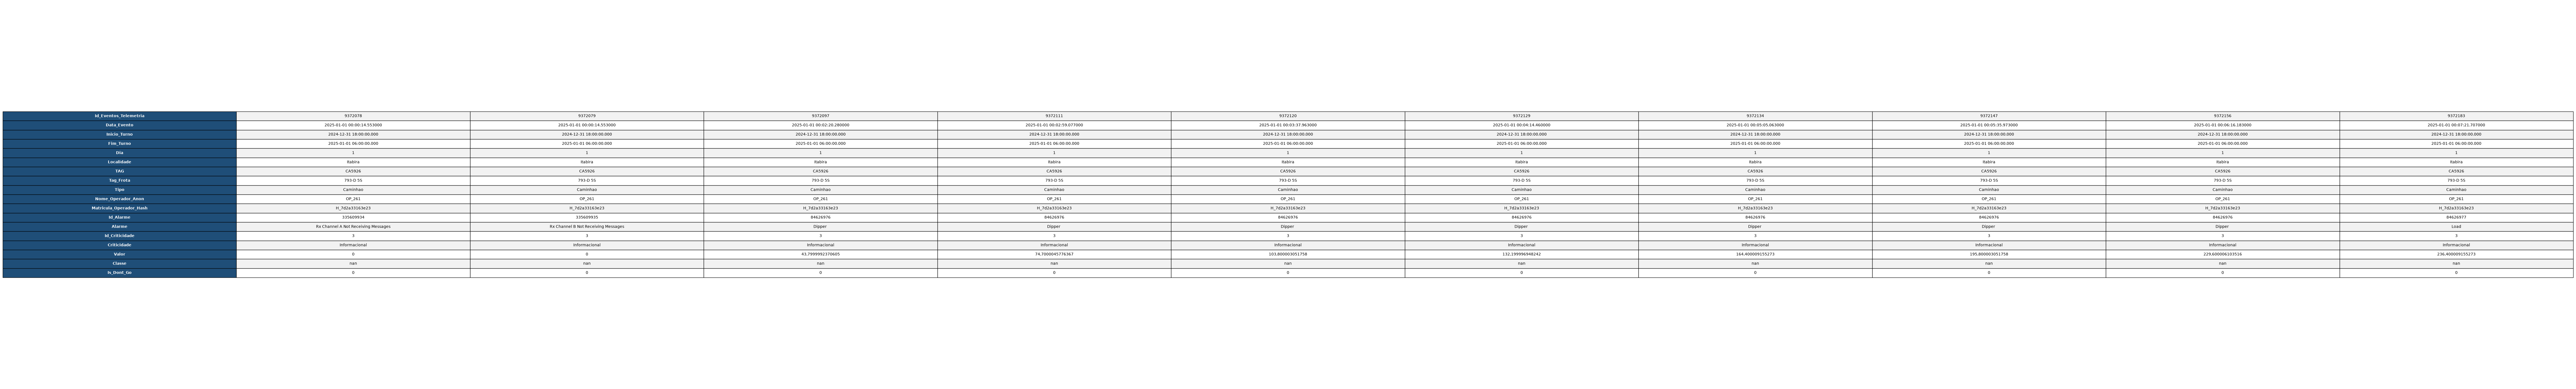

In [16]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# 1. Lendo os dados
df = jan
# Pegando as primeiras linhas
df_to_plot = df.head(10)

# --- TRANSPOSIÇÃO DOS DADOS ---
# Transpõe o DataFrame (.T) e transforma o índice (nomes das colunas originais) em uma coluna real
df_transposto = df_to_plot.T.reset_index()

# Configuração do tamanho da figura (ajustado para o formato vertical da transposição)
fig, ax = plt.subplots(figsize=(120, 18))
ax.axis("tight")
ax.axis("off")

# 2. Criar a tabela centralizada
# Como transcrevemos tudo para o corpo da tabela, não passamos 'colLabels' para não duplicar o cabeçalho no topo
the_table = ax.table(
    cellText=df_transposto.values,
    loc="center",
    cellLoc="center",
)

# 3. Travar o tamanho da fonte e dar espaçamento vertical (scale)
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.0, 2.0)  # Ajustado para 2.0 para manter um bom respiro vertical

# 4. Estilização Transposta (Coluna da esquerda escura, linhas alternadas no resto)
for (row, col), cell in the_table.get_celld().items():
    if col == 0:
        # Primeira coluna (antigo cabeçalho) fica em Azul Escuro
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#1F4E78")
    else:
        # Linhas alternadas em cinza claro para o restante dos dados
        if row % 2 == 0:
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

# 5. Salva no PDF primeiro
with PdfPages("alarmes_transposto.pdf") as pp:
    pp.savefig(fig, bbox_inches="tight", dpi=200)

# 6. MANDA PLOTAR NA TELA SUCESSO!
plt.show()

## 🔍 5. Diagnóstico de Valores Ausentes (Missing Values)

Mapeamento volumétrico e percentual de dados nulos por coluna. Essa análise é crítica para identificar quais atributos possuem baixa representatividade estatística e podem comprometer o aprendizado dos modelos.

Número de valores faltando.
Id_Eventos_Telemetria: 0 -> 0.00%
Data_Evento: 0 -> 0.00%
Inicio_Turno: 0 -> 0.00%
Fim_Turno: 0 -> 0.00%
Dia: 0 -> 0.00%
Localidade: 0 -> 0.00%
TAG: 0 -> 0.00%
Tag_Frota: 0 -> 0.00%
Tipo: 0 -> 0.00%
Nome_Operador_Anon: 0 -> 0.00%
Matricula_Operador_Hash: 0 -> 0.00%
Id_Alarme: 0 -> 0.00%
Alarme: 0 -> 0.00%
Id_Criticidade: 0 -> 0.00%
Criticidade: 0 -> 0.00%
Valor: 33666 -> 0.62%
Classe: 5290675 -> 97.98%
Is_Dont_Go: 0 -> 0.00%


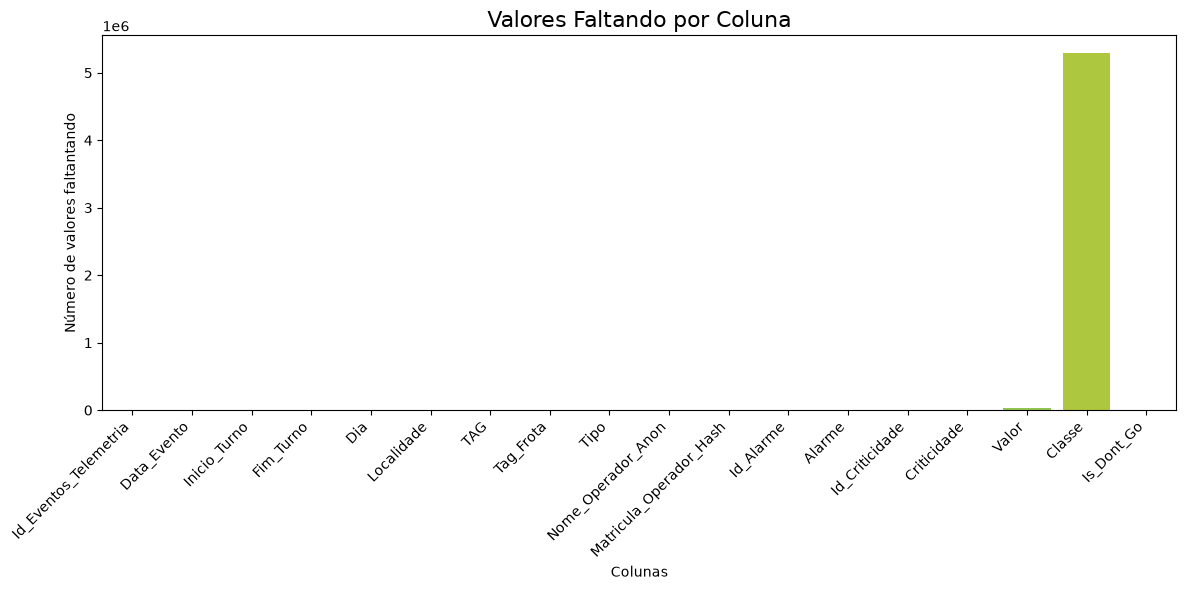

In [17]:


def show_missig_values(dataset):
    rows = dataset.shape[0]
    missing_counts = dataset.isnull().sum().reset_index()
    missing_counts.columns = ["coluna", "valores_faltantes"]
    
    print("Número de valores faltando.")
    for col, val in dataset.isnull().sum().items():
        print(f"{col}: {val} -> {val/rows*100:.2f}%")
    
    plt.figure(figsize=(12,6))
    sns.barplot(data=missing_counts, 
                x="coluna", 
                y="valores_faltantes",
                hue="coluna",
                palette="viridis",
                legend=False,
                dodge=False)
    
    plt.xticks(rotation=45, ha='right')
    plt.title("Valores Faltando por Coluna", fontsize=16)
    plt.xlabel("Colunas")
    plt.ylabel("Número de valores faltantando")
    plt.tight_layout()
    plt.show()
#for i in months:
#    show_missig_values(i)
show_missig_values(jan)

## 🔍 6. Higienização Inicial e Descarte de Atributos

Com base no diagnóstico de valores ausentes, iniciamos o descarte de colunas que não agregam valor preditivo ou que possuem uma taxa de nulidade impeditiva para modelagem (como a variável `Classe`, com 97% de dados faltantes).

In [18]:
jan = jan.drop(columns="Classe")
print(jan.shape)

(5400002, 17)


## 🔍 7. Análise de Distribuição e Variância de Atributos

Desenvolvimento de funções auxiliares para plotagem automatizada de histogramas (para dados numéricos) e gráficos de barras (para categóricos). O algoritmo aplica filtros automáticos para ignorar colunas de variância zero (constantes) ou de alta cardinalidade (chaves/IDs).

In [19]:
def show_distribution(dataset, cut_columns=[], max_categories=50000):
    """
    Exibe a distribuição de colunas relevantes, filtrando IDs, 
    colunas constantes e alta cardinalidade.
    """
    for col in dataset.columns:
        # 1. Filtro de colunas ignoradas manualmente
        if col in cut_columns:
            continue
            
        # 2. Filtro de Variância: Ignora se a coluna tiver apenas 1 valor único (ex: Localidade "Itabira" em tudo)
        unique_count = dataset[col].nunique()
        if unique_count <= 1:
            continue
            
        # 3. Filtro de IDs/Alta Cardinalidade: Se for ID ou Hash (muitos valores únicos em relação ao total)
        # Se mais de 90% dos dados forem únicos, provavelmente é um ID/Chave Primária
        if unique_count > len(dataset) * 0.9:
            continue

        plt.figure(figsize=(10, 5))
        
        # Lógica para colunas NUMÉRICAS
        if pd.api.types.is_numeric_dtype(dataset[col]):
            plt.title(f"Distribuição Numérica: '{col}'", fontsize=12)
            sns.histplot(dataset[col], color="skyblue", bins=30, stat="density", kde=True)
            plt.ylabel("Densidade")
            
        # Lógica para colunas CATEGÓRICAS
        else:
            # Se tiver categorias demais (ex: nomes de operadores), pegamos apenas as Top X
            if unique_count > max_categories:
                data_to_plot = dataset[col].value_counts().head(max_categories)
                plt.title(f"Top {max_categories} Categorias: '{col}'", fontsize=12)
            else:
                data_to_plot = dataset[col].value_counts()
                plt.title(f"Distribuição Categórica: '{col}'", fontsize=12)

            sns.barplot(x=data_to_plot.index, y=data_to_plot.values, palette="viridis", hue=data_to_plot.index, legend=False)
            plt.xticks(rotation=45, ha="right")
            plt.ylabel("Frequência")

        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

In [21]:
def particoes(month: pd.Series, n_chunks: int) -> list:
    chunk_size = len(month) // n_chunks
    
    
    return [month.iloc[i * chunk_size : (i + 1) * chunk_size] for i in range(n_chunks)]
    



In [22]:
partes = particoes(jan, 180)

print(partes[0])


       Id_Eventos_Telemetria                 Data_Evento  \
0                    9372078  2025-01-01 00:00:14.553000   
1                    9372079  2025-01-01 00:00:14.553000   
2                    9372097  2025-01-01 00:02:20.280000   
3                    9372111  2025-01-01 00:02:59.077000   
4                    9372120  2025-01-01 00:03:37.963000   
...                      ...                         ...   
29995               22923577  2025-01-31 00:13:53.397000   
29996               22923580  2025-01-31 00:14:03.000000   
29997               22923584  2025-01-31 00:14:04.550000   
29998               22923587  2025-01-31 00:14:09.477000   
29999               22923588  2025-01-31 00:14:11.217000   

                  Inicio_Turno                Fim_Turno  Dia Localidade  \
0      2024-12-31 18:00:00.000  2025-01-01 06:00:00.000    1    Itabira   
1      2024-12-31 18:00:00.000  2025-01-01 06:00:00.000    1    Itabira   
2      2024-12-31 18:00:00.000  2025-01-01 06:00:00.00

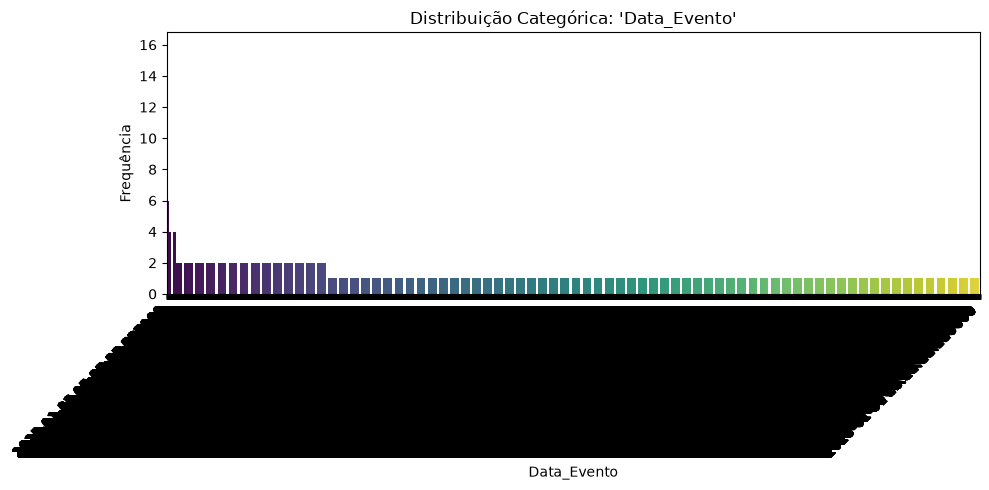

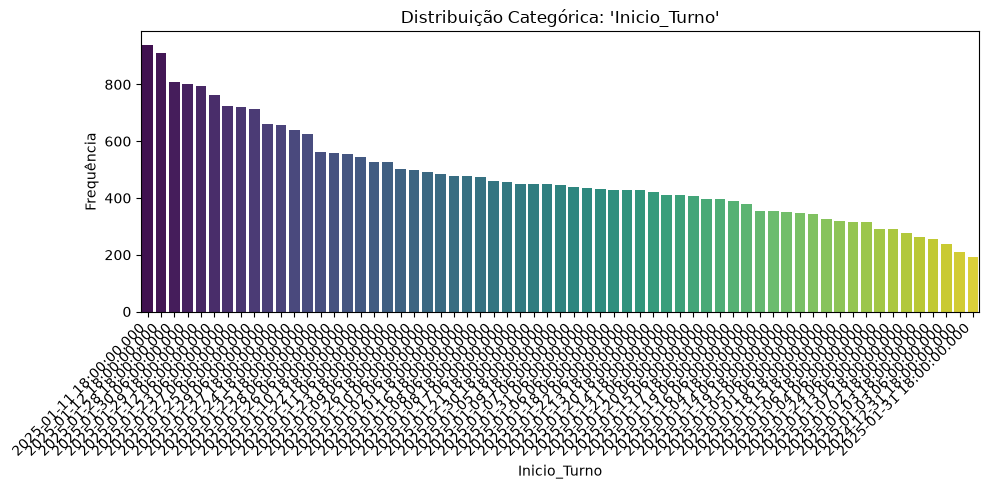

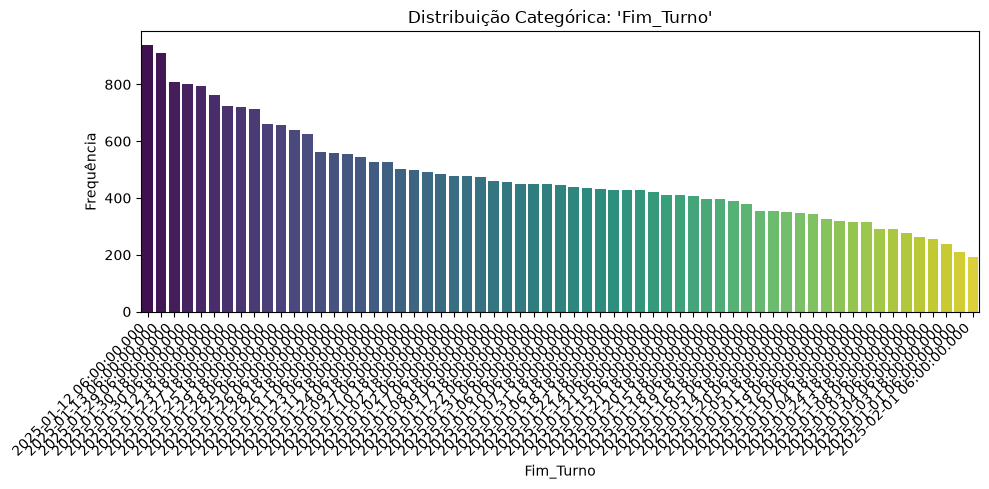

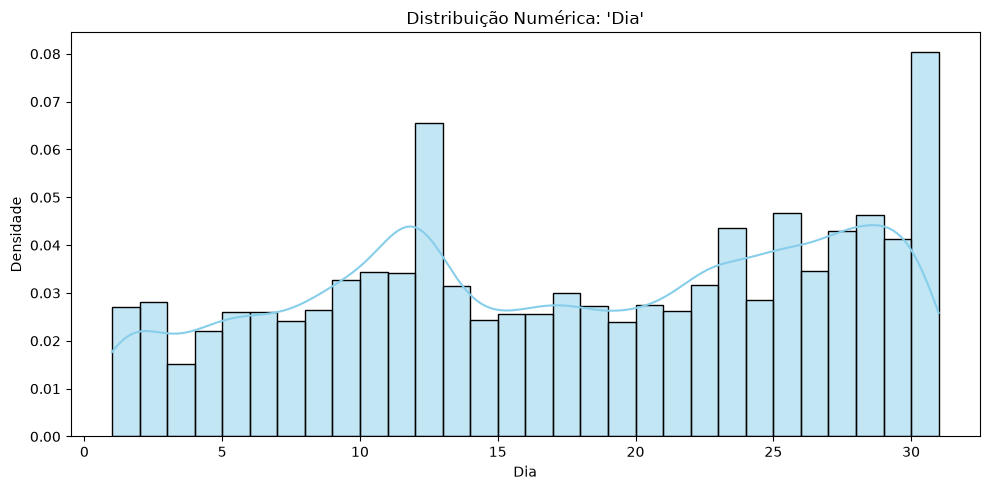

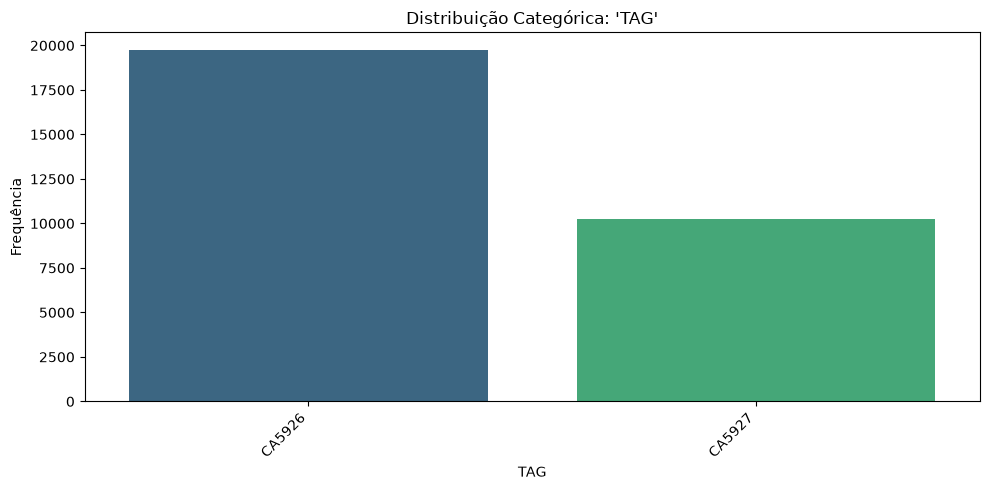

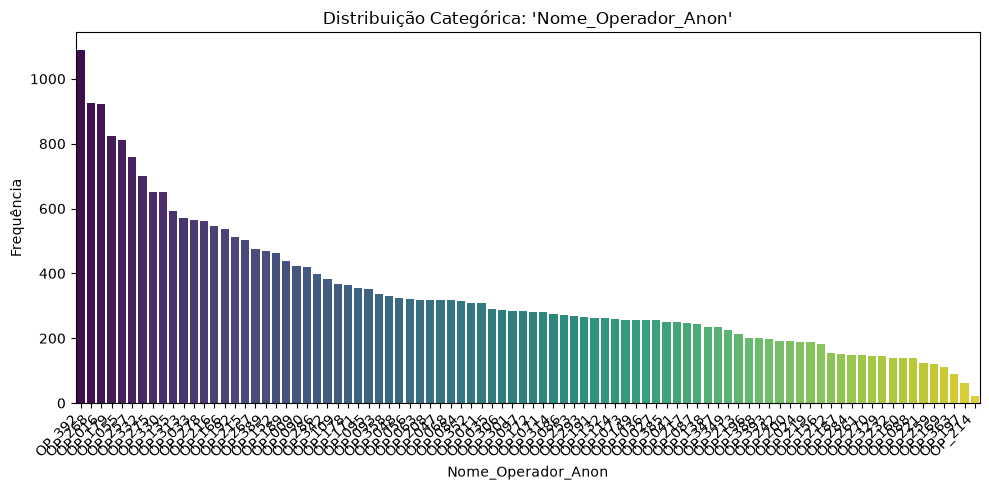

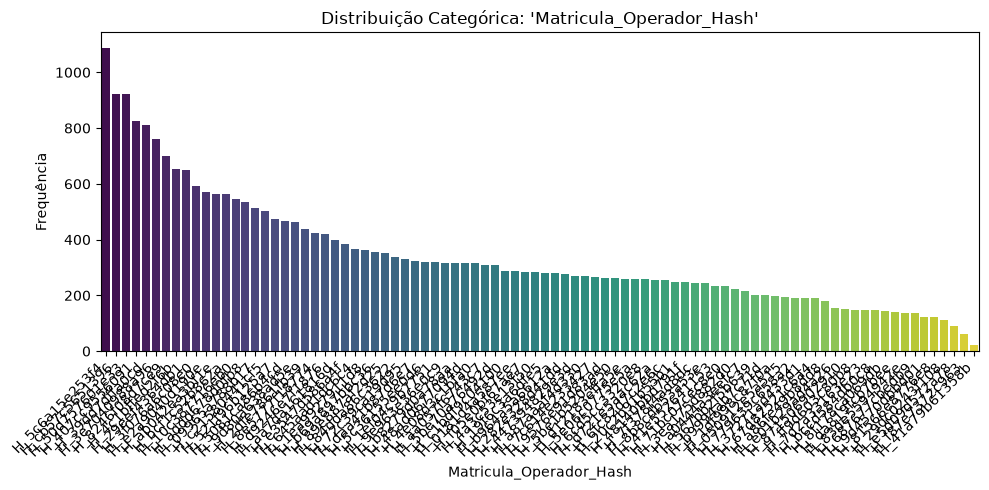

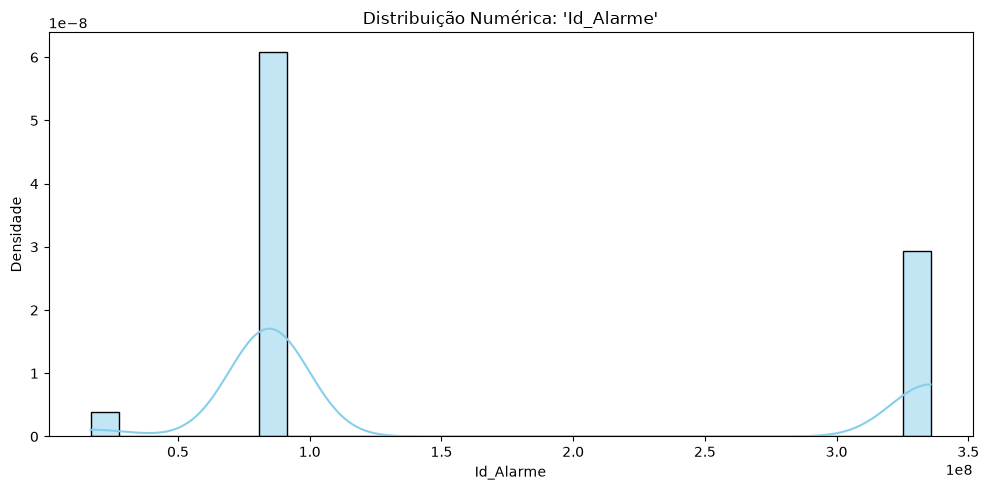

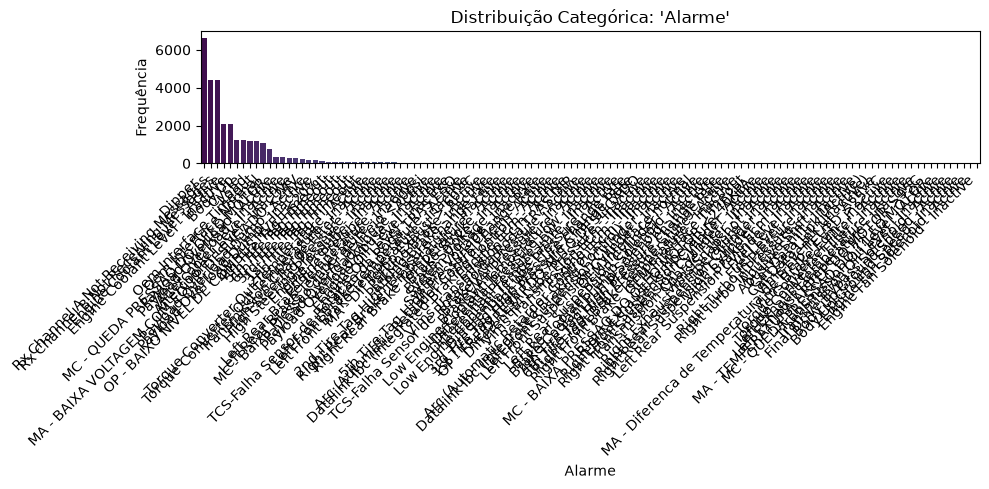

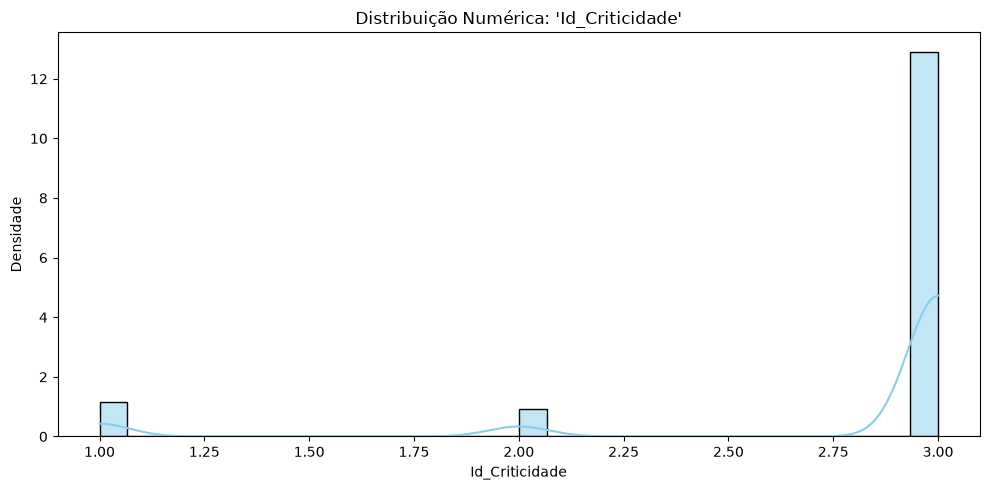

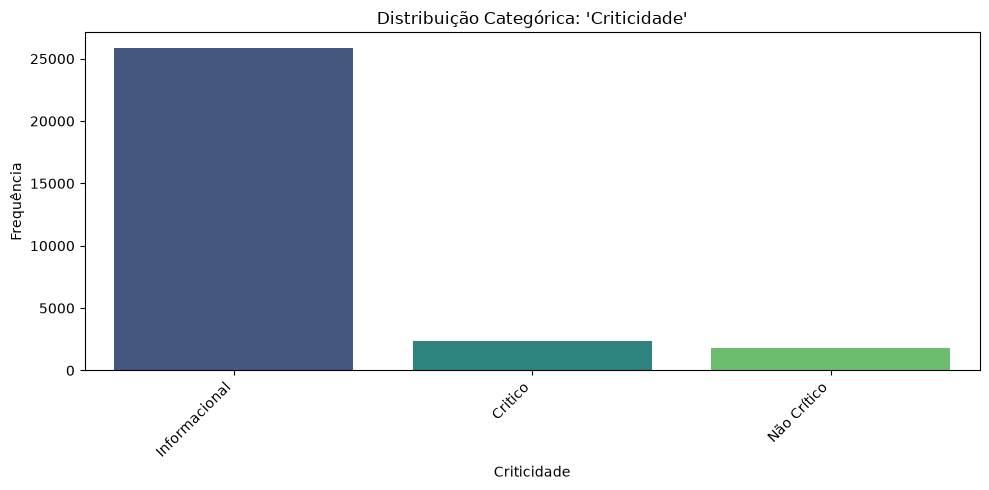

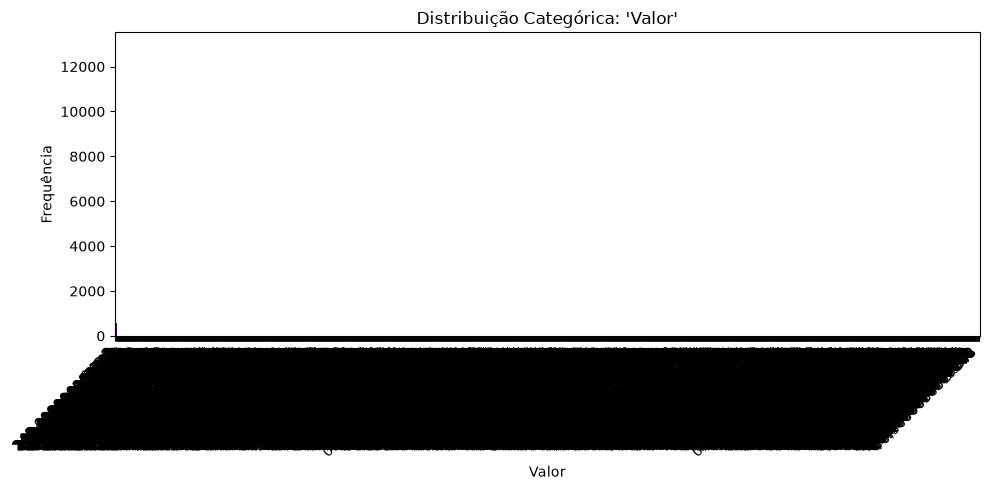

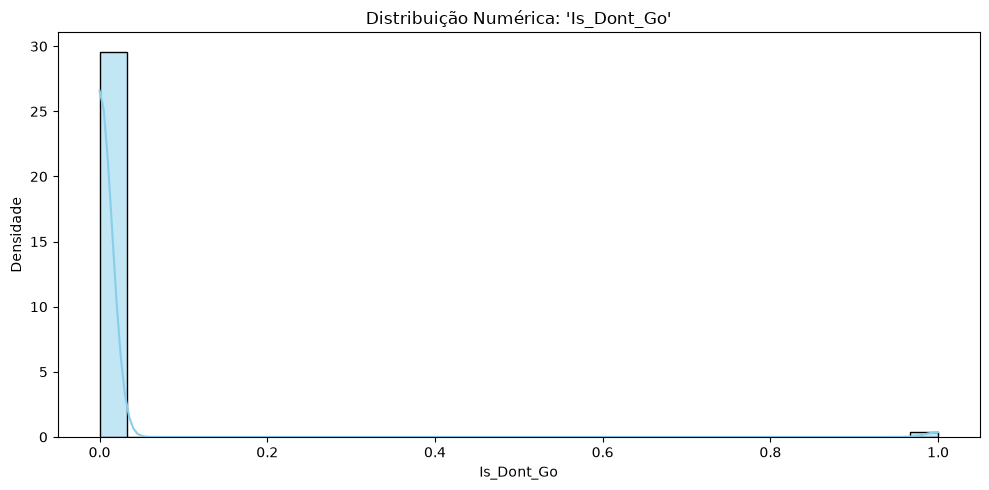

In [23]:
show_distribution(partes[0])

## 🔍 8. Questões de Negócio e Direcionamento Analítico

A partir da análise de distribuição e do comportamento inicial dos dados, mapeamos as seguintes dúvidas estratégicas e hipóteses a serem validadas junto aos especialistas de negócio:

- **Valores Ausentes:** Existem alarmes sem um valor correspondente. Essas linhas podem ser descartadas com segurança?
- **Sazonalidade:** As features de início e fim do turno podem ser agrupadas em categorias temporais (ex: Manhã 1, Manhã 2, Tarde 1, Tarde 2)?
- **Feature 'Classe':** Possui 97% de dados faltantes. Essa feature deve ser descartada do modelo?
- **IDs:** Os identificadores (IDs) devem ser tratados estritamente como variáveis categóricas?
- **Variedade de Alarmes:** Como lidar com a alta dimensionalidade dos tipos de alarmes, considerando que a visualização de todas as flags simultaneamente é impraticável?
- **Seleção de Features:** Quais atributos podem ser removidos sem causar perda de informação ou impacto preditivo?
- **Agrupamento Semântico:** É possível agrupar diferentes tipos de "Alarme"? (Ex: Se 'Freio' possui as categorias temperatura, pressão e auxiliar, eles podem ser unificados ou devem ser segregados por criticidade?)

## 🔍 9. Exploração de Redundâncias e Regras de Agrupamento Semântico

Investigação final sobre a correlação entre criticidade e o alvo `Is_Dont_Go`. Nesta etapa, removemos identificadores de linha (`Id_Eventos_Telemetria`), dados redundantes (`Nome_Operador_Anon`, `Dia`, `Localidade`) e testamos algoritmos de agrupamento semântico de strings para categorizar os tipos de alarmes por sistema automotivo afetado.

In [24]:
a = jan["Alarme"].unique()
b = jan["Criticidade"].unique()
a2 = jan["Alarme"]
b2 = jan["Criticidade"]
c = jan["Is_Dont_Go"]
d = jan["Tipo"].unique()
a, b, a2, b2, c, d

(<StringArray>
 [                      'Rx Channel A Not Receiving Messages',
                        'Rx Channel B Not Receiving Messages',
                                                    'Dipper ',
                                                       'Load',
                           'MC - QUEDA PRESSÃO DO ÓLEO MOTOR',
                                                    'Body Up',
                                                      'Cycle',
                                      'Oem Interface Timeout',
                                       'Oem Interface Normal',
                                  'Payload Overload - Active',
  ...
     'Front Service Brakes Pressure Sensor Or Cable Fail Low',
             'Steer Pump A Pressure Sensor Or Cable Fail Low',
                        'Fuel Level Sensor Or Cable Fail Low',
  'Hydraulic Reservoir Air Pressure Sensor Or Cable Fail Low',
                       'Hydraulic Reservoir Air Pressure Low',
                          'Hydraul

In [25]:
total = 0
casos = 0
for i in zip(b2, c):
    if i[0] == "Critico":
        total = total + 1
    if i[0] == "Critico" and i[1] == 1:
        casos = casos + 1
casos/total

vai=0
n_vai=0

for target in c:
   if target==0.0:
        vai = vai +1
   else:
        n_vai = n_vai + 1
n_vai, vai, n_vai+vai

(2581, 5397421, 5400002)

> ❓ **Dúvida Operacional:** Os dados indicam que apenas 7.7% dos casos críticos resultam em um evento *Don't Go*. Esta proporção reflete o comportamento real da frota ou há algum viés/erro de interpretação na extração da métrica?

In [26]:
jan= jan.drop(columns=['Id_Eventos_Telemetria'])
jan = jan.drop(columns=['Nome_Operador_Anon'])
jan = jan.drop(columns=['Dia'])


### 🧹 Remoção de Colunas Redundantes
Para otimizar o modelo e evitar ruídos, as seguintes colunas foram descartadas:
- **`Id_Eventos_Telemetria`**: Identificador único de linha (chave primária), sem poder preditivo.
- **`Nome_Operador_Anon`**: Redundante, pois a identidade já está mapeada de forma segura na coluna de *hash*.
- **`Dia`**: Informação redundante, já contemplada na variável `Data_Evento`.

In [27]:
print(jan.shape)
jan.head(5)

(5400002, 14)


,Data_Evento,Inicio_Turno,Fim_Turno,Localidade,TAG,Tag_Frota,Tipo,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Is_Dont_Go
0,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,0
1,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,0
2,2025-01-01 00:02:20.280000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",0
3,2025-01-01 00:02:59.077000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",0
4,2025-01-01 00:03:37.963000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",0


In [28]:
contador = 0
for i in jan["Localidade"]:
    if i == "Itabira":
        contador = contador + 1
contador

5400002

> 💡 **Nota de Descarte:** A coluna de Localidade indica apenas "Itabira" para todos os registros. Por ter variância nula (constante), ela não possui poder discriminatório e sua correlação com a variável alvo será sempre 0. Portanto, foi descartada.

In [29]:
jan = jan.drop(columns=['Localidade'])


In [30]:
tipos = jan["Tipo"].unique()
tipos

<StringArray>
['Caminhao', 'Escavadeira']
Length: 2, dtype: str

> 💡 **Nota sobre Veículos:** Atualmente, a base registra apenas "Caminhão" e "Escavadeira". É necessário validar com outras amostras (meses) se existem novos tipos de equipamentos. Caso seja restrito a esses dois, a variável poderá ser otimizada para um formato booleano (ex: `is_truck`).


In [31]:
print(jan.shape)

(5400002, 13)


In [32]:
def classificar_alarme_detalhado(nome_alarme):
    alarme = str(nome_alarme).upper()
    
    # ---------------------------------------------------------
    # 1. IDENTIFICAÇÃO DA SEVERIDADE (1 ou 2)
    # ---------------------------------------------------------
    # Palavras que indicam falha crítica, impacto direto ou parada
    criticos = ['MC -', 'MA -', 'ACTIVE', 'QUEDA', 'BAIXA PRESSÃO', 'FALHA', 'LOW PRESSURE', '>']
    
    # Palavras que indicam aviso, timeout, inatividade ou operação
    avisos = ['OP -', 'INACTIVE', 'TIMEOUT', 'NORMAL', 'CHANGE RATE', 'ABUSE', 'DUMP', 'LEVEL']
    
    # Define a severidade inicial
    severidade = "1" # Padrão é 1 (Aviso/Menos grave)
    if any(c in alarme for c in criticos) and not any(a in alarme for a in ['INACTIVE', 'NORMAL']):
        severidade = "2" # Se for crítico e NÃO estiver inativo/normal, vira 2

    # ---------------------------------------------------------
    # 2. IDENTIFICAÇÃO DO SISTEMA
    # ---------------------------------------------------------
    sistema = "Outros" # Categoria padrão se não achar nenhuma
    
    # Dicionário de sistemas e suas palavras-chave
    regras_sistemas = {
        "Motor": ['ENGINE', 'COOLANT', 'OIL', 'AFTERCOOLER', 'TURBO', 'EXHAUST', 'ARREF', 'COMBUSTÍVEL', 'PRELUBE', 'FAN'],
        "Freio": ['BRAKE', 'FREIO', 'IBC', 'ARC', 'RETARDO', 'PARKING'],
        "Transmissao": ['TRANSMISSION', 'TORQUE CONVERTER', 'SHIFT', 'DIFFERENTIAL', 'FINAL DRIVE', 'MARCHA'],
        "Suspensao_Lataria": ['SUSPENSION', 'STEERING', 'DIREÇÃO', 'CHASSIS'],
        "Pneu": ['TIRE', 'PNEU'],
        "Carga": ['PAYLOAD', 'DIPPER', 'LOAD', 'CYCLE', 'BODY UP'],
        "Eletronica": ['ECM', 'DATA LINK', 'VIMS', 'CHANNEL', 'OEM', 'VOLTAGEM', 'VOLTAGE', 'SENSOR']
    }
    
    # Busca qual sistema o alarme pertence
    for chave_sistema, palavras_chave in regras_sistemas.items():
        if any(palavra in alarme for palavra in palavras_chave):
            sistema = chave_sistema
            break # Achou o sistema, para de procurar
            
    # ---------------------------------------------------------
    # 3. RETORNA A COMBINAÇÃO (Ex: Freio2, Motor1, Pneu1)
    # ---------------------------------------------------------
    return f"{sistema}{severidade}"

In [33]:
novo = []
for alarme in partes[0]["Alarme"]:
    novo.append(classificar_alarme_detalhado(alarme))
novo
#classificar_alarme(partes[0]["Alarme"])

['Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Freio2',
 'Freio2',
 'Freio1',
 'Freio1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'C

> ❓ **Dúvida de Negócio:** É viável e correto (do ponto de vista operacional) agrupar "Avisos Operacionais" e "Não Críticos" em uma única categoria de criticidade para simplificar a modelagem?

In [35]:
head_jan = jan.head()
head_jan

# Exibe o head com cabeçalho destacado, linhas de grade explícitas e alinhamento centralizado
head_jan.style.set_properties(**{
    'background-color': 'white',
    'color': 'black',
    'border': '1px solid #D3D3D3',       # Adiciona linhas entre linhas e colunas
    'text-align': 'center',              # Centraliza o texto das células
    'padding': '8px'
}).set_table_styles([
    {
        'selector': 'th', 
        'props': [
            ('background-color', '#1F4E78'), 
            ('color', 'white'), 
            ('font-weight', 'bold'),
            ('border', '1px solid #D3D3D3'), # Adiciona as linhas no cabeçalho também
            ('text-align', 'center'),
            ('padding', '10px')
        ]
    }
])

,Data_Evento,Inicio_Turno,Fim_Turno,TAG,Tag_Frota,Tipo,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Is_Dont_Go
0,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,0
1,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,0
2,2025-01-01 00:02:20.280000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",0
3,2025-01-01 00:02:59.077000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",0
4,2025-01-01 00:03:37.963000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",0


In [36]:
import matplotlib.pyplot as plt

# 1. Configurando a estrutura gráfica da tabela
fig, ax = plt.subplots(figsize=(50, 2.5)) # Ajuste o tamanho baseado na quantidade de colunas
ax.axis('tight')
ax.axis('off')

# 2. Criando a tabela integrada com os dados do dataframe
table = ax.table(
    cellText=head_jan.values,
    colLabels=head_jan.columns,
    cellLoc='center',
    loc='center'
)

# 3. Ajustando proporções de espaçamento e fontes
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.8) # Alarga as linhas verticalmente para um aspecto profissional

# 4. Aplicando a estilização das bordas, cabeçalho e preenchimento
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#B0B0B0')  # Linhas divisórias cinzas explícitas
    cell.set_linewidth(1.2)        # Espessura da linha separadora
    
    if row == 0:
        # Cabeçalho Azul Escuro padrão do projeto
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1F4E78')
    else:
        # Linhas de dados com sutil alternância de fundo para melhor leitura
        if row % 2 == 0:
            cell.set_facecolor('#F9FBFD')
        else:
            cell.set_facecolor('#FFFFFF')

# 5. Salvando nos formatos solicitados com alta resolução
plt.savefig('head_janeiro.png', bbox_inches='tight', dpi=300)
plt.savefig('head_janeiro.svg', bbox_inches='tight')
plt.close()

print("Imagens 'head_janeiro.png' e 'head_janeiro.svg' geradas com sucesso!")

Imagens 'head_janeiro.png' e 'head_janeiro.svg' geradas com sucesso!


In [37]:
# Substitua o 'caminho_e_nome_do_arquivo.csv' pelo local onde deseja salvar
jan.to_csv('jan_limpo.csv', index=False)